In [138]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random

In [139]:
def drawLossGraph(equation_names = [], histories = [], rows = 2, cols = 2, figsize = (16, 9)):
    if len(equation_names) != len(histories):
        raise Exception('size do not match')
    
    plt.figure(figsize=figsize)

    for index, history in enumerate(histories):
        plt.subplot(rows, cols, index + 1)
        plt.plot(history['loss'][1:], label = 'train loss')
        plt.plot(history['val_loss'][1:], label = 'validation loss', linestyle = '--')
        plt.title(equation_names[index])
        plt.xlabel('Epoch')
        plt.ylabel('MSE')
        plt.legend()

    plt.suptitle('Training Loss VS Validation Loss')
    plt.tight_layout()
    plt.show()

In [140]:
def drawTestGraph(equation_names = [], models = [], x_test = None, y_tests  = [], rows = 2, cols = 2, figsize = (16, 9)):
    if len(equation_names) != len(models):
        raise Exception('size do not match')
    
    plt.figure(figsize=figsize)

    for index, model in enumerate(models):
        y_test = y_tests[index]
        y_test_predict = model.predict(x_test)
        plt.subplot(rows, cols, index + 1)
        plt.scatter(x_test, y_test, label = 'actual', marker = 'o')
        plt.scatter(x_test, y_test_predict, label = 'predicted', marker = 'x')
        plt.title(equation_names[index])
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.legend()

    plt.suptitle('Actual VS Predicted')
    plt.tight_layout()
    plt.show()

In [141]:
def eq1(x):
    y = 5*x + 10
    return y

def eq2(x):
    y = 3*x**2 + 5*x + 10
    return y

def eq3(x):
    y = 4*x**3 + 3*x**2 + 5*x + 10
    return y

In [142]:
equation_names = ['5x + 10', '3x^2 + 5x + 10', '4x^3 + 3x^2 + 5x + 10']
dataset_size = 100000
train_split = int(0.8 * dataset_size)
low = -100
high = 100

In [143]:
x = np.linspace(low, high, dataset_size)
random.shuffle(x)
x_train = x[:train_split]
x_test = x[train_split:]
x_train = np.array(x_train)
x_test = np.array(x_test)
x_mean = x_train.mean()
x_std = x_train.std()
x_train = (x_train - x_mean) / x_std
x_test = (x_test - x_mean) / x_std
print(x_train.shape, x_test.shape)

(80000,) (20000,)


In [144]:
y_train1 = eq1(x_train)
y_test1 = eq1(x_test)
y_mean1 = y_train1.mean()
y_std1 = y_train1.std()
y_train1 = (y_train1 - y_mean1) / y_std1
y_test1 = (y_test1 - y_mean1) / y_std1
print(y_train1.shape, y_test1.shape)

(80000,) (20000,)


In [145]:
y_train2 = eq2(x_train)
y_test2 = eq2(x_test)
y_mean2 = y_train2.mean()
y_std2 = y_train2.std()
y_train2 = (y_train2 - y_mean2) / y_std2
y_test2 = (y_test2 - y_mean2) / y_std2
print(y_train2.shape, y_test2.shape)

(80000,) (20000,)


In [146]:
y_train3 = eq3(x_train)
y_test3 = eq3(x_test)
y_mean3 = y_train3.mean()
y_std3 = y_train3.std()
y_train3 = (y_train3 - y_mean3) / y_std3
y_test3 = (y_test3 - y_mean3) / y_std3
print(y_train3.shape, y_test3.shape)

(80000,) (20000,)


In [147]:
model1 = Sequential([
    layers.Input(shape = (1,)),
    layers.Dense(2, activation='relu'),
    layers.Dense(1, activation=None),
])
model1.summary(show_trainable=True)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ dense_62 (Dense)            │ (None, 2)             │          4 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_63 (Dense)            │ (None, 1)             │          3 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [148]:
model2 = Sequential([
    layers.Input(shape = (1,)),
    layers.Dense(4, activation='relu'),
    layers.Dense(2, activation='relu'),
    layers.Dense(1, activation=None),
])
model2.summary(show_trainable=True)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ dense_64 (Dense)            │ (None, 4)             │          8 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_65 (Dense)            │ (None, 2)             │         10 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_66 (Dense)            │ (None, 1)             │          3 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [149]:
model3 = Sequential([
    layers.Input(shape = (1,)),
    layers.Dense(8, activation='relu'),
    # layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='relu'),
    # layers.Dense(16, activation='relu'),
    # layers.Dense(2, activation='relu'),
    layers.Dense(2, activation='relu'),
    layers.Dense(1, activation=None),
])
model3.summary(show_trainable=True)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ dense_67 (Dense)            │ (None, 8)             │         16 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_68 (Dense)            │ (None, 4)             │         36 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_69 (Dense)            │ (None, 2)             │         10 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_70 (Dense)            │ (None, 1)             │          3 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [150]:
model1.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
)

In [151]:
model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
)

In [152]:
model3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='mse',
)

In [153]:
history1 = model1.fit(x_train, y_train1, epochs=20, batch_size=32, validation_split=.1)
model1.evaluate(x_test, y_test1)


Epoch 1/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.3705 - val_loss: 0.9809
Epoch 2/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7096 - val_loss: 0.4979
Epoch 3/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.3667 - val_loss: 0.2616
Epoch 4/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2048 - val_loss: 0.1539
Epoch 5/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1236 - val_loss: 0.0927
Epoch 6/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0721 - val_loss: 0.0514
Epoch 7/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0383 - val_loss: 0.0256
Epoch 8/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0180 - val_loss: 0.0111
Epoch 9/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0073 - val_loss: 0.0040
Epoch 10/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 11/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.9948e-04 - val_loss: 2.1839e-04
Epoch 12/20
2250/2250 

1.858778105393033e-12

In [154]:
history2 = model2.fit(x_train, y_train2, epochs=20, batch_size=32, validation_split=.1)
model2.evaluate(x_test, y_test2)

Epoch 1/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3053 - val_loss: 0.1158
Epoch 2/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0402 - val_loss: 0.0161
Epoch 3/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0155 - val_loss: 0.0144
Epoch 4/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0134 - val_loss: 0.0124
Epoch 5/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0080 - val_loss: 0.0069
Epoch 6/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0062 - val_loss: 0.0056
Epoch 7/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 8/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 9/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 10/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 11/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 12/20
2250/2250 ━━━━━━━━

0.0007801029714755714

In [155]:
history3 = model3.fit(x_train, y_train3, epochs=20, batch_size=32, validation_split=.1)
model3.evaluate(x_test, y_test3)

Epoch 1/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.4902 - val_loss: 0.2709
Epoch 2/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2118 - val_loss: 0.1692
Epoch 3/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1505 - val_loss: 0.1297
Epoch 4/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1133 - val_loss: 0.0884
Epoch 5/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0670 - val_loss: 0.0469
Epoch 6/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0357 - val_loss: 0.0252
Epoch 7/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0191 - val_loss: 0.0133
Epoch 8/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0099 - val_loss: 0.0067
Epoch 9/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0049 - val_loss: 0.0032
Epoch 10/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 11/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0012 - val_loss: 8.3714e-04
Epoch 12/20
2250/2250 ━━━━

0.0003078650333918631

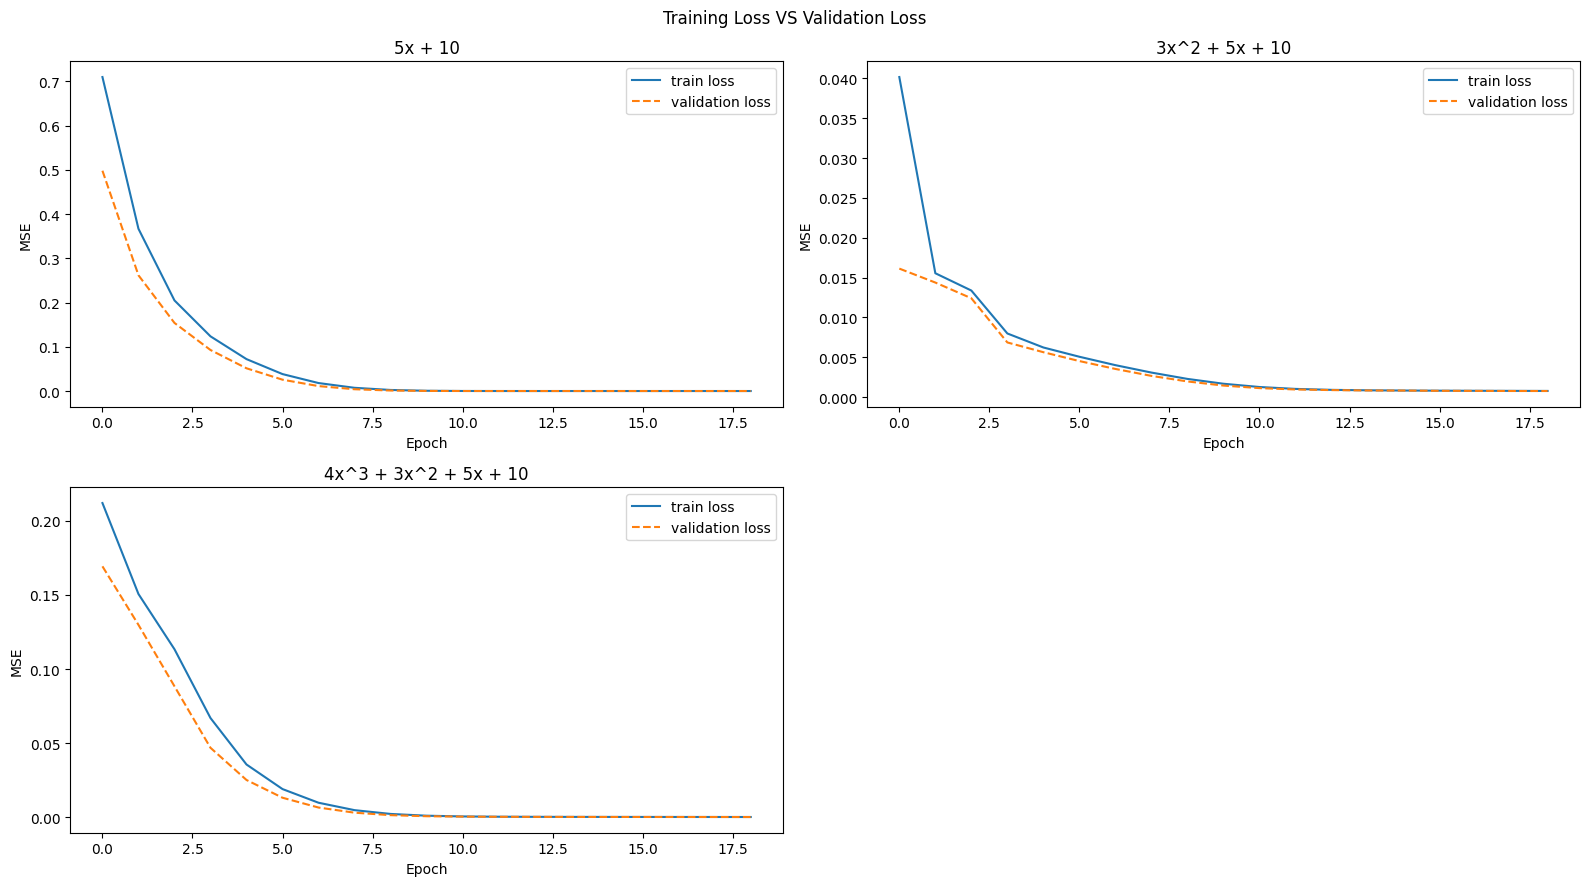

In [156]:
drawLossGraph(equation_names=equation_names, histories=[history1.history, history2.history, history3.history])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


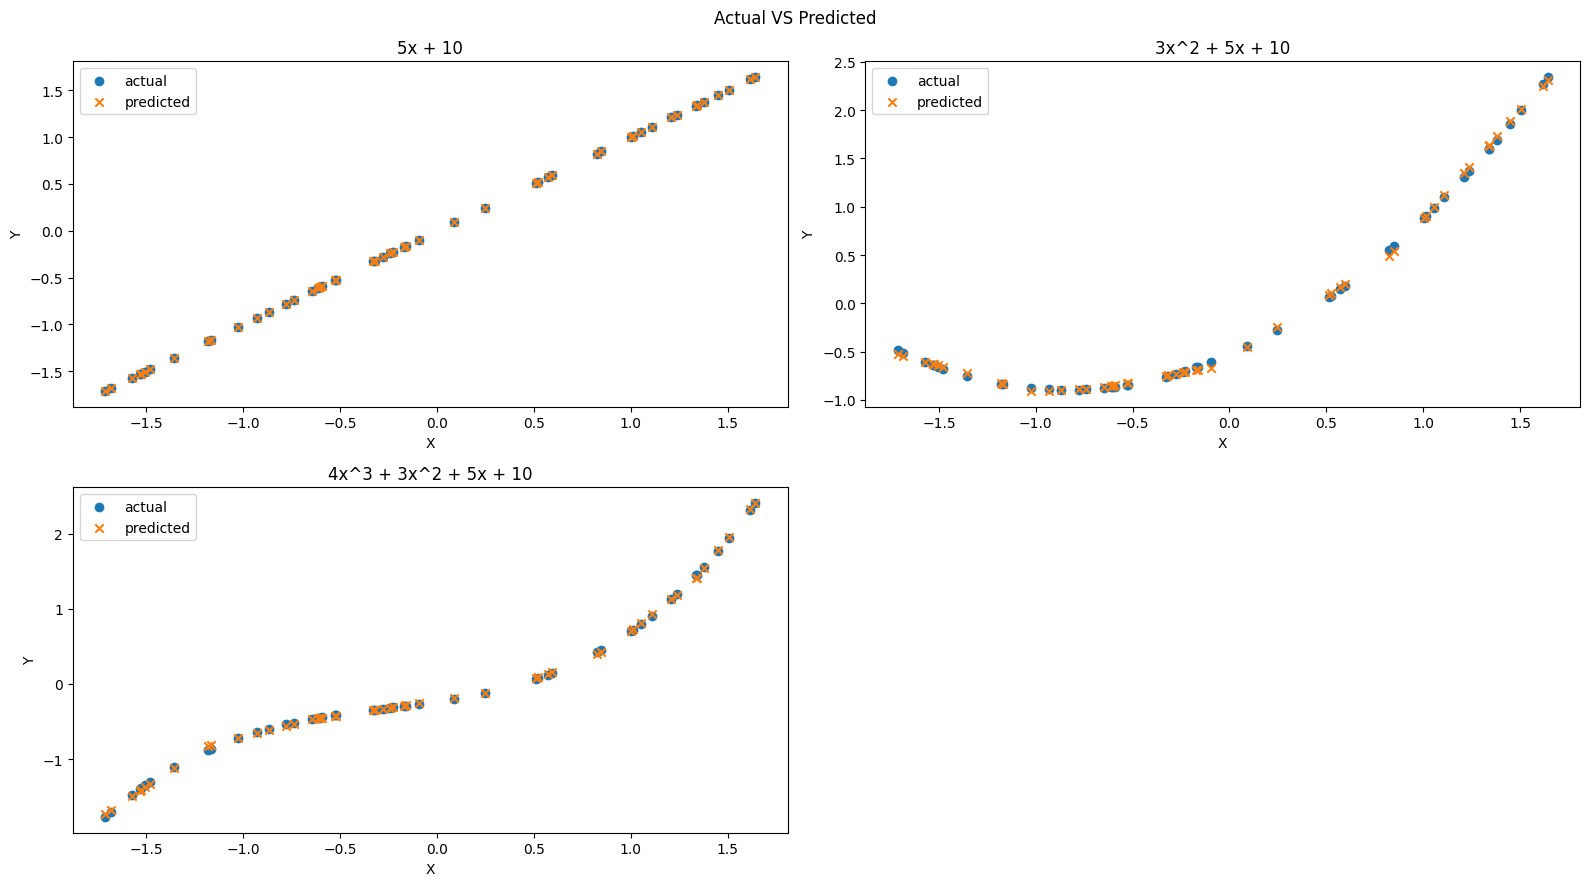

In [157]:
drawTestGraph(equation_names=equation_names, models = [model1, model2, model3], x_test=x_test[:50], y_tests=[y_test1[:50], y_test2[:50], y_test3[:50]])